# **Credit Card Churning Customers Data Analysis**

## Objectives

* Find and download dataset from Kaggle
* Clean Data: Deal with outliers, missing and/or duplicated entries
* Statistical Analysis: Identifying the significance between variable relationship

## Inputs

* Credit Card customers dataset which can be found [here](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

## Outputs

* Cleaned_Data and Transformed_Data 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [4]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [5]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [6]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-'

# Section 1

**Load data and install libraries**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df=pd.read_csv('./Data/Raw_Data/BankChurners.csv')
df.head(8)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.99994
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.99988
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.99991


In [57]:
df.tail(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


In [36]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

(10127, 23)

I noticed the dataset had two columns with Naive_Bayes_classifiers which I recongnised as a Machine Learning method as my knowledge of this method is limited I asked co-pilot what this feature was and if I should keep it, the response was "Those two long Naive_Bayes_Classifier columns are pre‑computed Naive Bayes probability predictions created by IBM. They are not real features and should be removed because they leak information and bias your model" hence why these two columns were removed.

It was also mentioned on the kaggle page to delete these two columns

The Client Number column was also removed as this has no predictive value it doesnt help with EDA or machine learning modelling and also can be considered as sensitive infomation. It could be used to identify a person of be linked back to an indivduals account.

In [37]:
df = df.drop([
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2',
    'CLIENTNUM'
], axis=1)

---

In [38]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

(10127, 20)

In [39]:
df.isnull().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [40]:
df.duplicated().sum()

0

In [41]:
df.dtypes

Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [42]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


# Section 2: Transform

**Outlier Detection**

========Before Outlier Treatment========


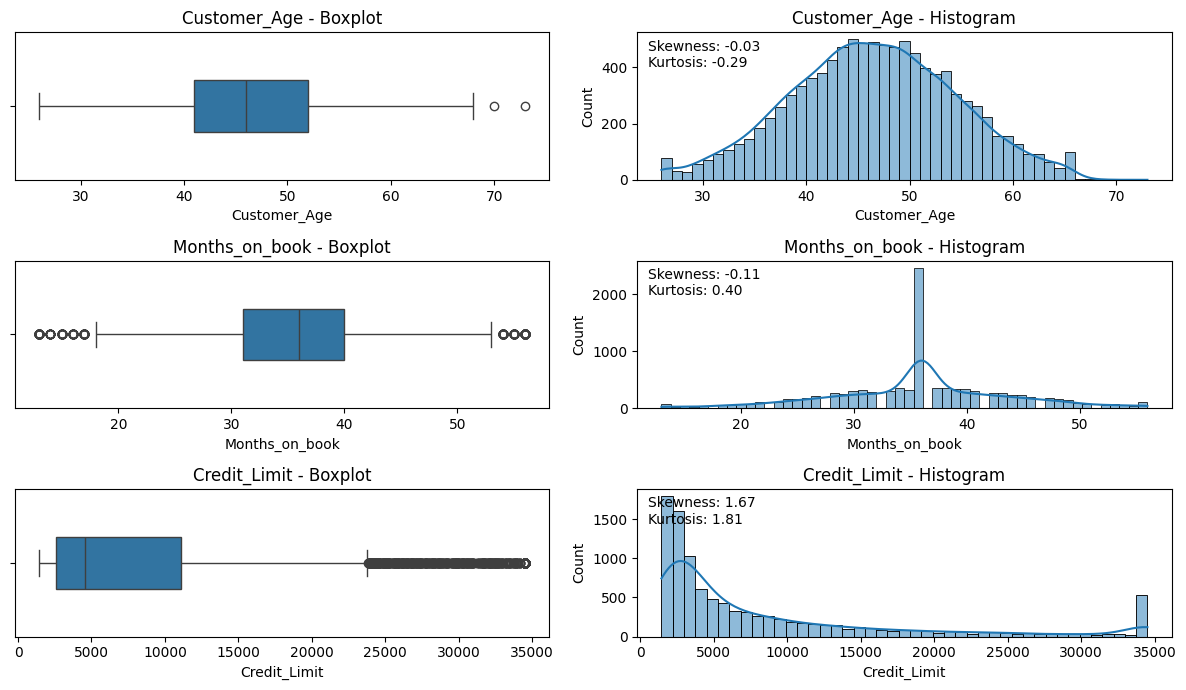

In [43]:
print("========Before Outlier Treatment========")
selected_cols = ['Customer_Age', 'Months_on_book','Credit_Limit']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df[col].skew():.2f}\nKurtosis: {df[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

========Before Outlier Treatment========


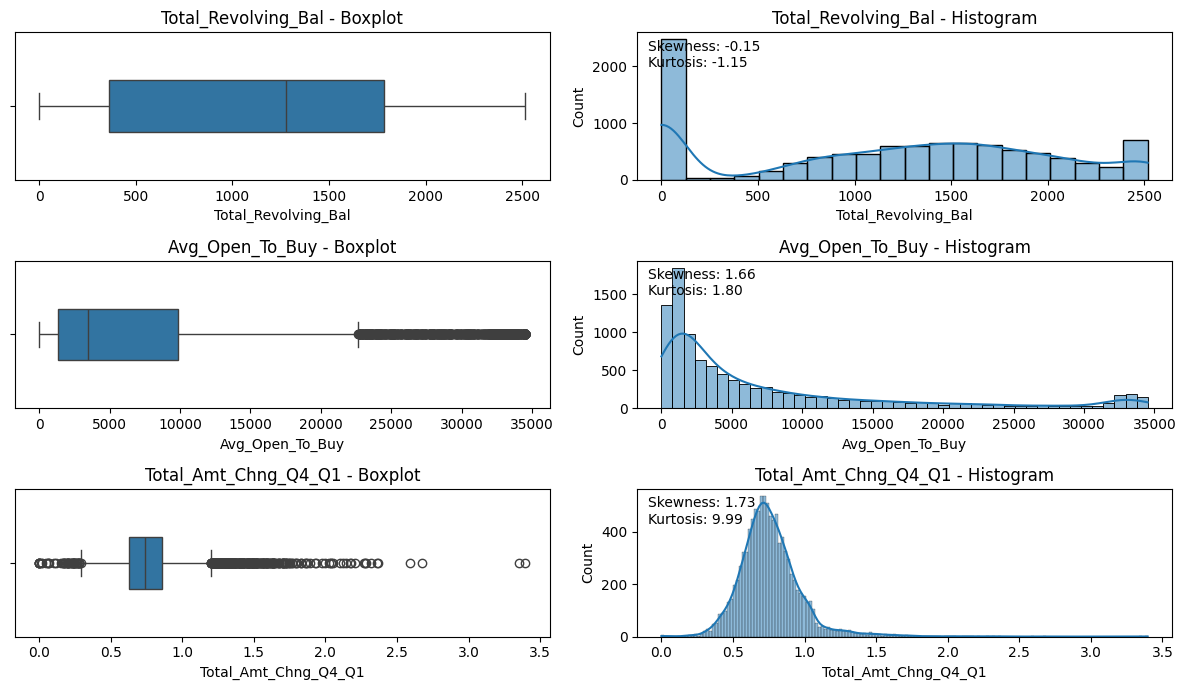

In [44]:
print("========Before Outlier Treatment========")
selected_cols = ['Total_Revolving_Bal', 'Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df[col].skew():.2f}\nKurtosis: {df[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

========Before Outlier Treatment========


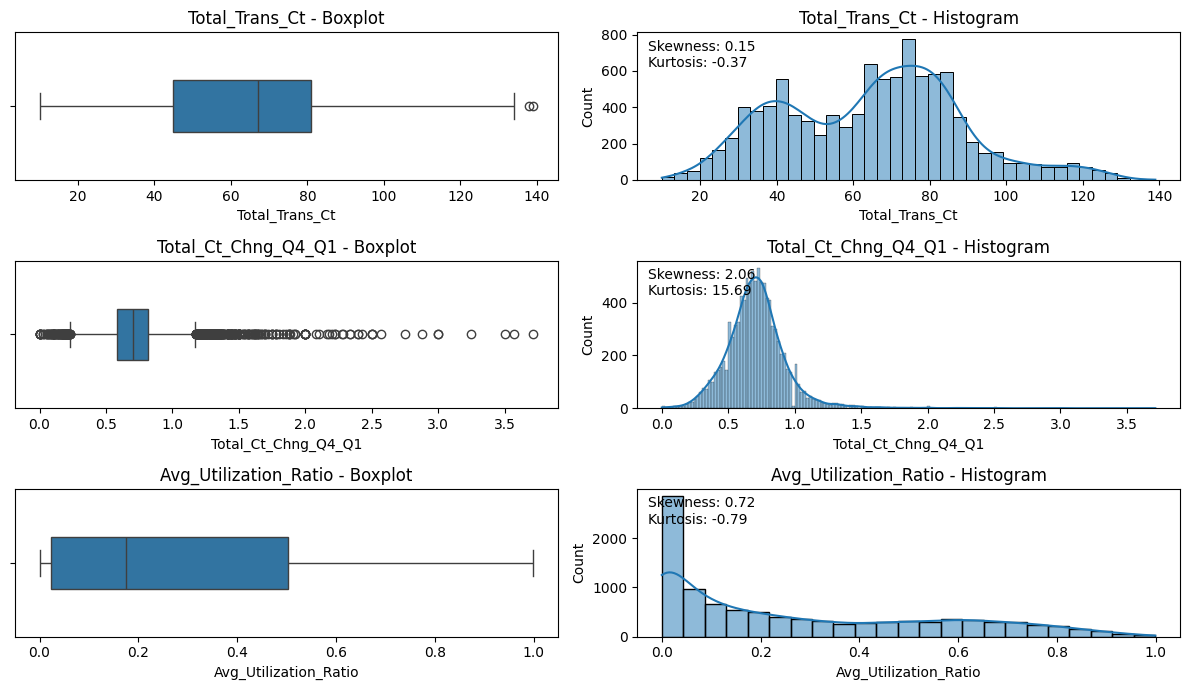

In [45]:
print("========Before Outlier Treatment========")
selected_cols = ['Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df[col].skew():.2f}\nKurtosis: {df[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

In [46]:
# Keep only numeric columns so strings/categorical values don't break stats
numeric_df = df_transformed.select_dtypes(include='number')

ser_skew = numeric_df.skew()
ser_skew.name = 'skewness'

ser_kurt = numeric_df.kurtosis()
ser_kurt.name = 'kurtosis'

summary_stats = numeric_df.describe()
summary_stats.loc['skewness'] = ser_skew
summary_stats.loc['kurtosis'] = ser_kurt

summary_stats

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.945394,3.812580,2.341167,2.455317,7882.309381,1162.814061,6720.676247,0.751387,4404.086304,64.858695,0.703484,0.274894
std,8.016814,1.298908,7.773496,1.554408,1.010622,1.106225,7217.091225,814.987335,7223.542192,0.184542,3397.129254,23.472570,0.197203,0.275691
min,26.000000,0.000000,17.500000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.289000,510.000000,10.000000,0.228000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,53.500000,6.000000,6.000000,6.000000,23836.250000,2517.000000,22660.750000,1.201000,18484.000000,139.000000,1.172000,0.999000
skewness,-0.033605,-0.020826,-0.063500,-0.162452,0.633061,0.011006,1.197249,-0.148837,1.190498,0.329036,2.041003,0.153673,0.129075,0.718008
kurtosis,-0.288620,-0.683017,0.071256,-1.006131,1.098523,0.000863,0.085967,-1.145992,0.067205,0.131033,3.894023,-0.367163,0.090811,-0.794972


**Winsorizer - Capping Outliers**

In [ ]:
from feature_engine.outliers import Winsorizer  # Import Winsorizer to cap extreme values (outliers) using statistical rules
from sklearn.pipeline import Pipeline  # Import Pipeline to chain preprocessing steps (here, Winsorizer) into one fit/transform workflow
pipeline = Pipeline([
    ('winsorizer_iqr', Winsorizer(capping_method = 'iqr', fold=1.5, tail='both', variables = ['Months_on_book','Credit_Limit','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Ct_Chng_Q4_Q1']))
])
df_transformed = pipeline.fit_transform(df)
df_transformed.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39.0,5,1,3,12691.00,777,11914.00,1.201,1144,42,1.172,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44.0,6,1,2,8256.00,864,7392.00,1.201,1291,33,1.172,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4,1,0,3418.00,0,3418.00,1.201,1887,20,1.172,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34.0,3,4,1,3313.00,2517,796.00,1.201,1171,20,1.172,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21.0,5,1,0,4716.00,0,4716.00,1.201,816,28,1.172,0.000
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3,1,2,4010.00,1247,2763.00,1.201,1088,24,0.846,0.311
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46.0,6,1,3,23836.25,2264,22660.75,1.201,1330,31,0.722,0.066
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2,2,2,23836.25,1396,22660.75,1.201,1538,36,0.714,0.048


In [48]:
# Display the upper bound thresholds used by the Winsorizer to cap outliers in the right tail
# This shows the maximum values that outliers are capped

pipeline['winsorizer_iqr'].right_tail_caps_

{'Months_on_book': 53.5,
 'Credit_Limit': 23836.25,
 'Avg_Open_To_Buy': 22660.75,
 'Total_Amt_Chng_Q4_Q1': 1.201,
 'Total_Ct_Chng_Q4_Q1': 1.172}

In [49]:
# Display the lower bound thresholds used by the Winsorizer to cap outliers in the left tail
# This shows the minimum values that outliers are capped to for 

pipeline['winsorizer_iqr'].left_tail_caps_

{'Months_on_book': 17.5,
 'Credit_Limit': -10213.75,
 'Avg_Open_To_Buy': -11477.25,
 'Total_Amt_Chng_Q4_Q1': 0.28900000000000003,
 'Total_Ct_Chng_Q4_Q1': 0.22799999999999998}

========After Outlier Treatment========


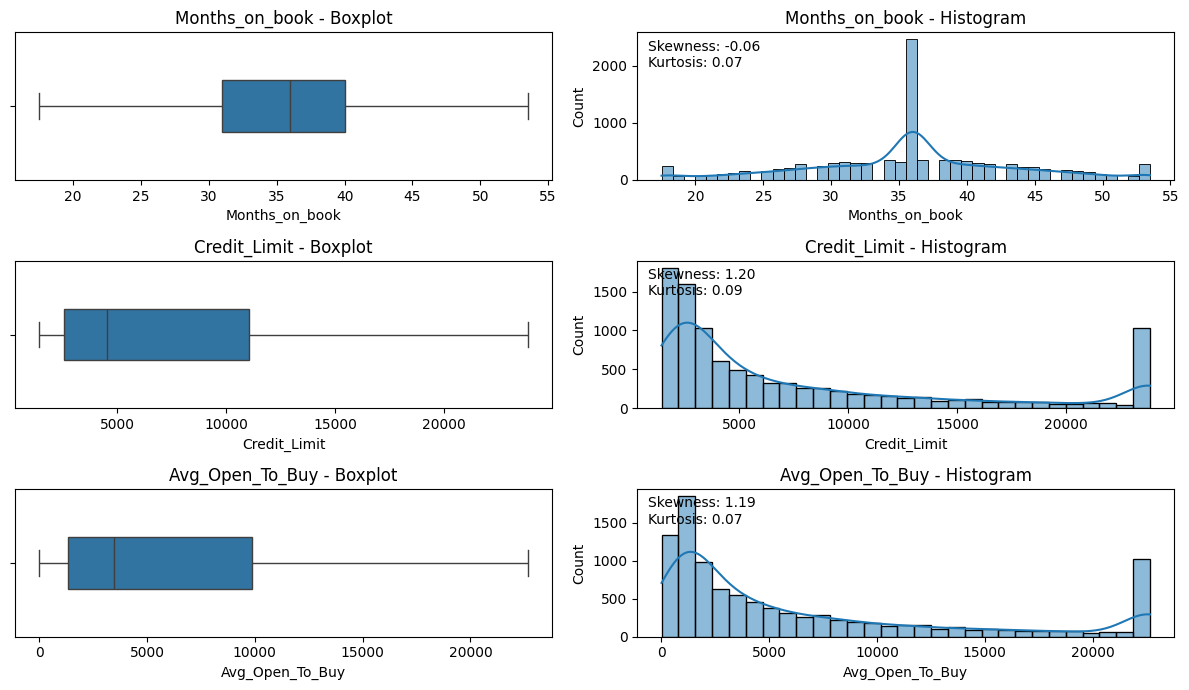

In [50]:
print("========After Outlier Treatment========")
selected_cols = ['Months_on_book','Credit_Limit','Avg_Open_To_Buy']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df_transformed, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df_transformed, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df_transformed[col].skew():.2f}\nKurtosis: {df_transformed[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

========After Outlier Treatment========


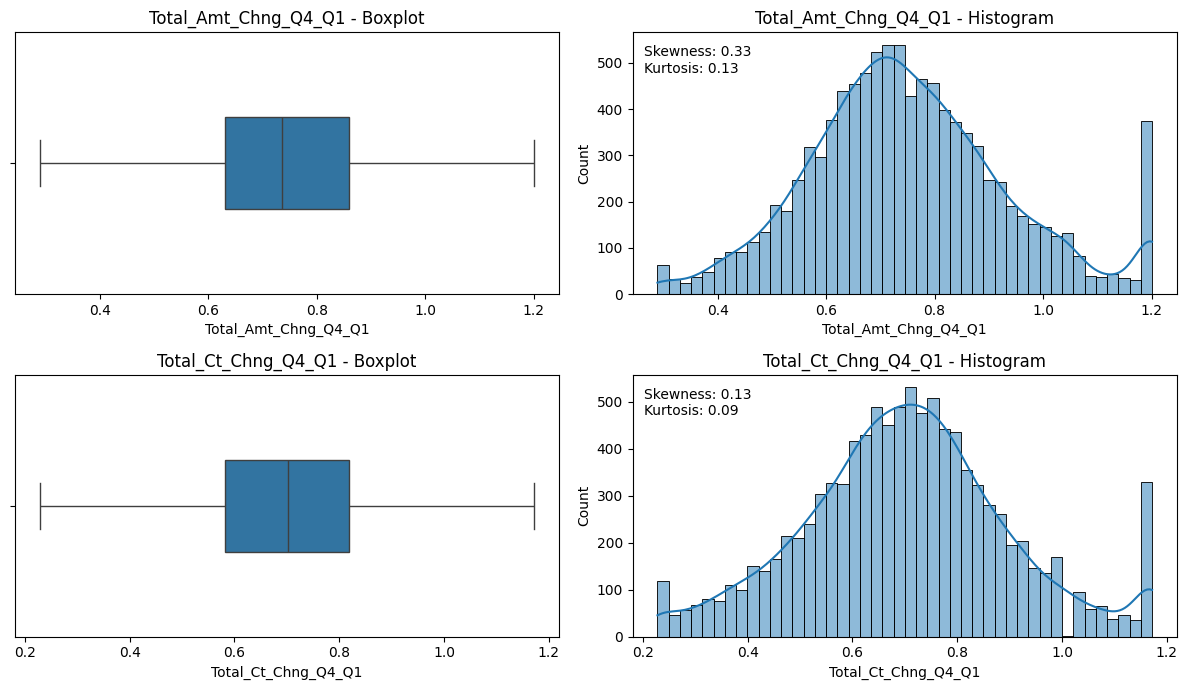

In [51]:
print("========After Outlier Treatment========")
selected_cols = ['Total_Amt_Chng_Q4_Q1','Total_Ct_Chng_Q4_Q1']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df_transformed, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df_transformed, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df_transformed[col].skew():.2f}\nKurtosis: {df_transformed[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

**Q-Q Plot - Understanding Data Distribution**

In [52]:
# Create a count plot to visualize the distribution of each categorical variable
for col in df_transformed.select_dtypes(include='object').columns:
    print(f"{df[col].value_counts()} \n\n")

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64 


Gender
F    5358
M    4769
Name: count, dtype: int64 


Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64 


Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64 


Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64 


Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64 




**Important Obervation**
The distribution of the target variable Attrition_Flag is highly imbalanced. This imbalance is important because it can negatively affect the performance of machine learning models. Many algorithms tend to learn patterns from the majority class and may struggle to correctly identify attrited customers, leading to: biased predictions, poor recall for the minority class. This will be explored further during the machine learning stage.

Note: you may need to restart the kernel to use updated packages.


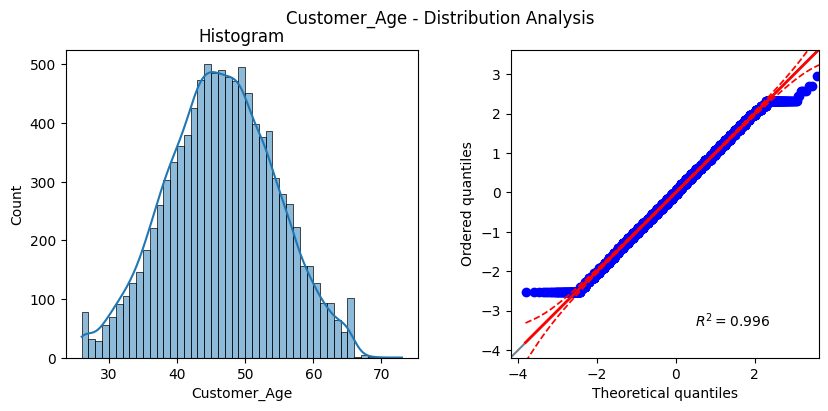

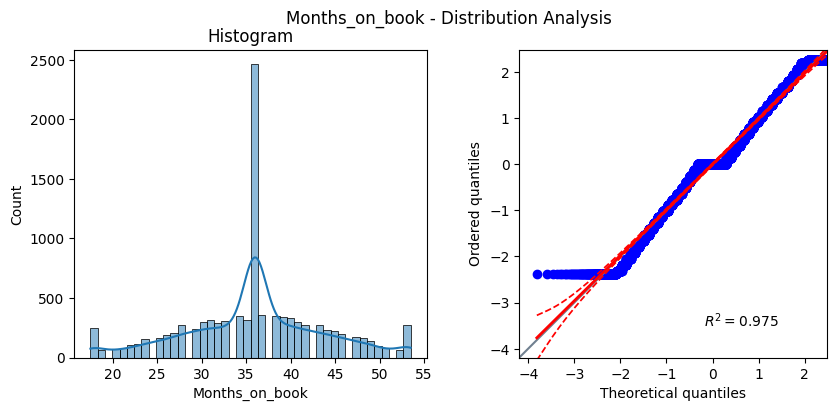

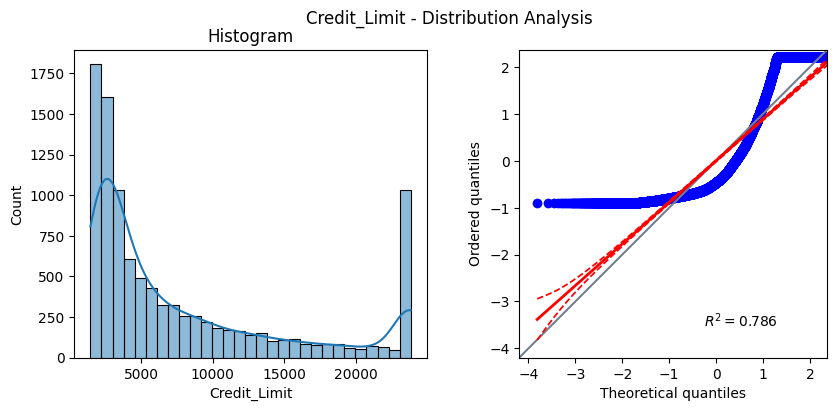

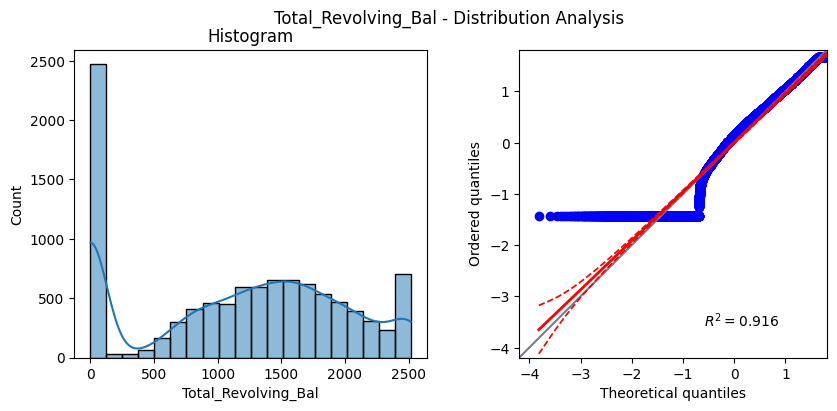

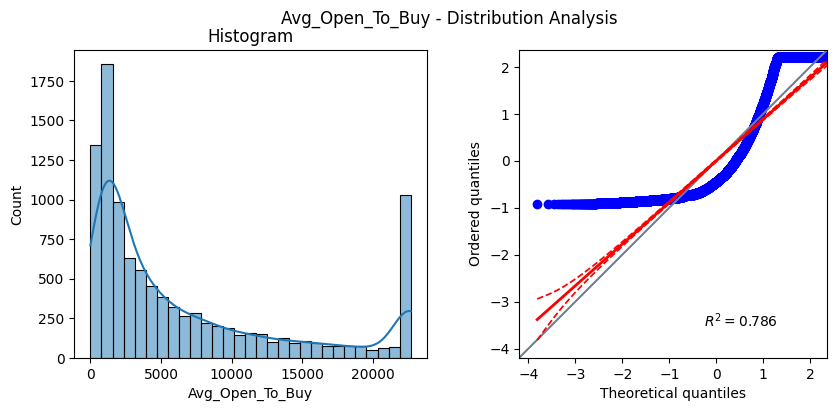

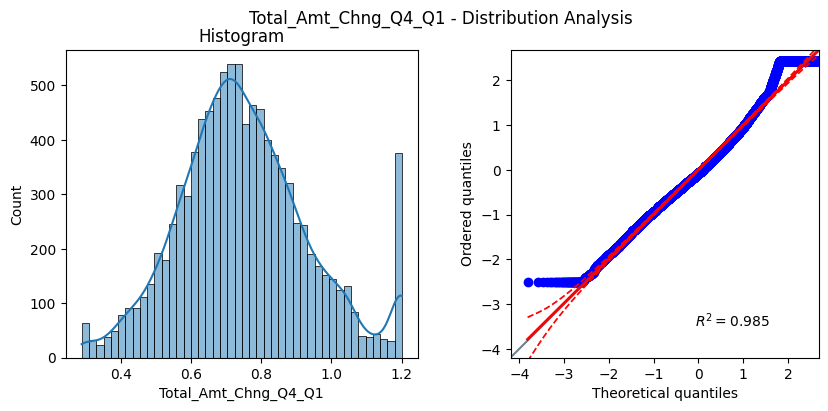

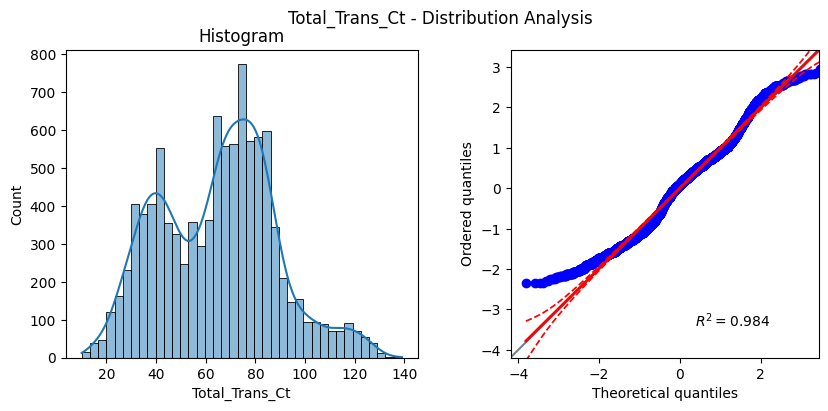

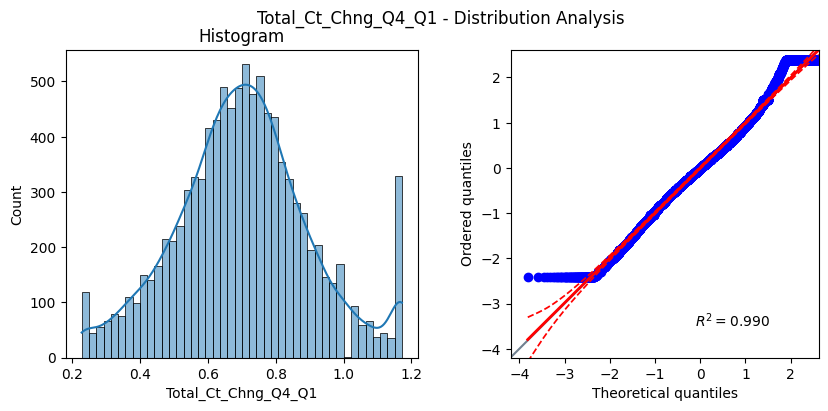

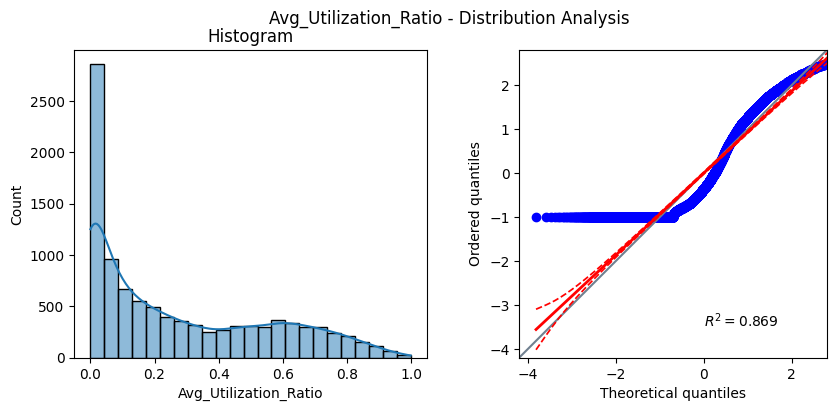

In [53]:
%pip install pingouin

import pingouin as pg

# Only loop through specific numeric columns for Q-Q plots
numeric_cols = ['Customer_Age', 'Months_on_book','Credit_Limit','Total_Revolving_Bal', 'Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio']

for col in numeric_cols:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    sns.histplot(data=df_transformed, x=col, kde=True, ax=axes[0])
    axes[0].set_title("Histogram")
    pg.qqplot(df_transformed[col], dist='norm', ax=axes[1])
    fig.suptitle(f"{col} - Distribution Analysis")
    plt.show()
    print('\n')

Cleaned_Data: This dataset contains the original data after removing unnecessary columns, handling duplicated records, and treating missing values where appropriate.
It represents a clean but unaltered version of the data, meaning no outlier treatment has been applied.

Tranformed_Data: Is cleaned data but but includes outlier treatment (winsorization).
The purpose of this transformation is to create a version of the data that is more suitable for visualisation and exploratory analysis, where extreme values can distort plots and hide underlying patterns.

The reason for the two datasets is the transformed data by capping or removing extreme values, the visualisations become more interpretable and less misleading, allowing clearer insights into the general behaviour of the variables.
 The cleaned data with the outliers will be used for the Machine Learning algorithms the outliers are kept as they are real observations, not errors and Tree‑based models handle outliers naturally. This ensures the machine learning algorithms learn from the full range of customer behaviour, including rare but meaningful patterns.

In [54]:
df.to_csv("Cleaned_Data.csv", index=False)

In [55]:
df_transformed.to_csv("Transformed_Data.csv", index=False)

---